In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv('breast-cancer.csv')

In [5]:
data.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
435,908489,M,13.98,19.62,91.12,599.5,0.1060,0.11330,0.11260,0.06463,...,17.04,30.80,113.90,869.3,0.1613,0.3568,0.4069,0.18270,0.3179,0.10550
536,91979701,M,14.27,22.55,93.77,629.8,0.1038,0.11540,0.14630,0.06139,...,15.29,34.27,104.30,728.3,0.1380,0.2733,0.4234,0.13620,0.2698,0.08351
189,874839,B,12.30,15.90,78.83,463.7,0.0808,0.07253,0.03844,0.01654,...,13.35,19.59,86.65,546.7,0.1096,0.1650,0.1423,0.04815,0.2482,0.06306
170,87139402,B,12.32,12.39,78.85,464.1,0.1028,0.06981,0.03987,0.03700,...,13.50,15.64,86.97,549.1,0.1385,0.1266,0.1242,0.09391,0.2827,0.06771
422,906616,B,11.61,16.02,75.46,408.2,0.1088,0.11680,0.07097,0.04497,...,12.64,19.67,81.93,475.7,0.1415,0.2170,0.2302,0.11050,0.2787,0.07427


In [6]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


<Axes: >

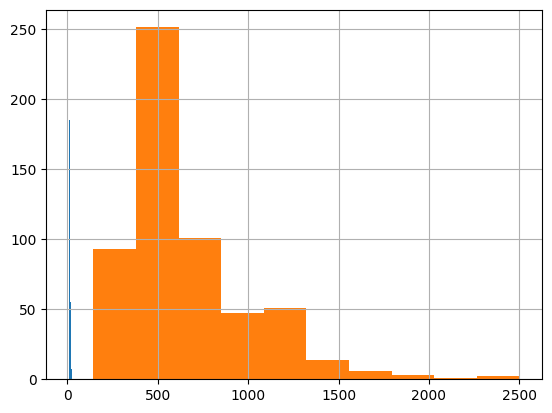

In [16]:
# data.value_counts().plot(kind = 'bar')
data['radius_mean'].hist()
data['area_mean'].hist()

<Axes: >

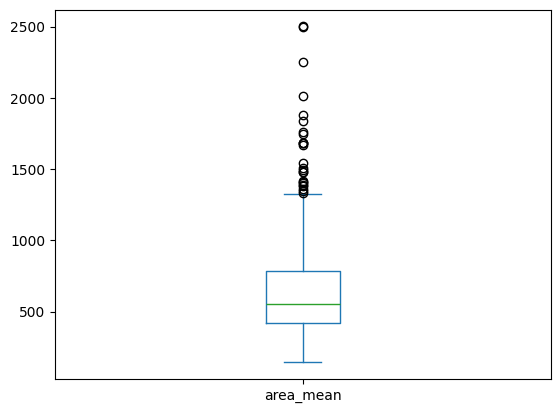

In [18]:
# To check if the data contains outliers
data['area_mean'].plot(kind = 'box')

# Train Test Split

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(data.drop('diagnosis', axis = 1),
                                                              data['diagnosis'],
                                                              test_size = 0.3,
                                                              random_state = 0)
X_train.shape, X_test.shape

((398, 31), (171, 31))

# Standard Scaler

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
scaler.mean_

array([3.04731366e+07, 1.41855000e+01, 1.91928392e+01, 9.23355025e+01,
       6.61859045e+02, 9.64749497e-02, 1.04080000e-01, 8.87943058e-02,
       4.94785528e-02, 1.80698241e-01, 6.26464573e-02, 4.09096231e-01,
       1.20445829e+00, 2.86661859e+00, 4.13843643e+01, 6.98354020e-03,
       2.50993719e-02, 3.12257678e-02, 1.16784749e-02, 2.04023819e-02,
       3.73508116e-03, 1.63596206e+01, 2.55345226e+01, 1.07736030e+02,
       8.94246985e+02, 1.32529045e-01, 2.53368894e-01, 2.68530796e-01,
       1.15221410e-01, 2.89186935e-01, 8.37181407e-02])

In [34]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [35]:
np.round(X_train.describe(), 1)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,...,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0
mean,30473136.6,14.2,19.2,92.3,661.9,0.1,0.1,0.1,0.0,0.2,...,16.4,25.5,107.7,894.2,0.1,0.3,0.3,0.1,0.3,0.1
std,127565034.3,3.6,4.2,24.8,366.6,0.0,0.1,0.1,0.0,0.0,...,5.0,6.1,34.5,597.9,0.0,0.2,0.2,0.1,0.1,0.0
min,8670.0,7.0,9.7,43.8,143.5,0.1,0.0,0.0,0.0,0.1,...,7.9,12.0,50.4,185.2,0.1,0.0,0.0,0.0,0.2,0.1
25%,865715.5,11.7,16.0,75.3,420.4,0.1,0.1,0.0,0.0,0.2,...,13.1,20.9,84.1,516.4,0.1,0.1,0.1,0.1,0.2,0.1
50%,905501.5,13.3,18.7,86.1,548.4,0.1,0.1,0.1,0.0,0.2,...,14.9,25.2,97.5,682.0,0.1,0.2,0.2,0.1,0.3,0.1
75%,8811826.2,15.8,21.6,104.5,779.1,0.1,0.1,0.1,0.1,0.2,...,19.0,29.5,125.8,1093.2,0.1,0.3,0.4,0.2,0.3,0.1
max,911320502.0,28.1,33.8,188.5,2501.0,0.1,0.3,0.4,0.2,0.3,...,36.0,49.5,251.2,4254.0,0.2,1.1,1.1,0.3,0.7,0.2


In [36]:
np.round(X_train_scaled.describe(), 1)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,...,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0,398.0
mean,-0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,...,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-0.2,-2.0,-2.3,-2.0,-1.4,-3.2,-1.7,-1.1,-1.3,-2.7,...,-1.7,-2.2,-1.7,-1.2,-2.7,-1.5,-1.4,-1.8,-2.1,-1.6
25%,-0.2,-0.7,-0.8,-0.7,-0.7,-0.7,-0.7,-0.7,-0.7,-0.7,...,-0.7,-0.8,-0.7,-0.6,-0.7,-0.7,-0.8,-0.8,-0.7,-0.7
50%,-0.2,-0.2,-0.1,-0.3,-0.3,-0.0,-0.2,-0.3,-0.4,-0.1,...,-0.3,-0.1,-0.3,-0.4,-0.0,-0.2,-0.2,-0.2,-0.1,-0.2
75%,-0.2,0.4,0.6,0.5,0.3,0.6,0.5,0.5,0.7,0.5,...,0.5,0.6,0.5,0.3,0.6,0.5,0.6,0.7,0.5,0.5
max,6.9,3.9,3.5,3.9,5.0,3.5,4.1,4.3,3.9,4.4,...,4.0,3.9,4.2,5.6,3.9,5.2,4.3,2.7,5.9,6.9


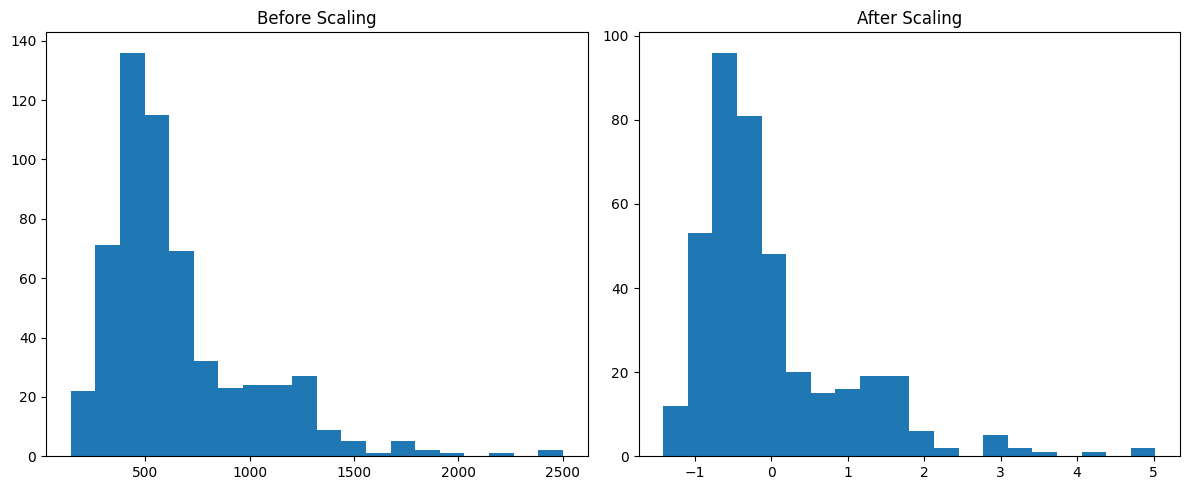

In [38]:
import matplotlib.pyplot as plt

feature = 'area_mean'

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data[feature], bins=20)
plt.title("Before Scaling")

plt.subplot(1,2,2)
plt.hist(X_train_scaled[feature], bins=20)
plt.title("After Scaling")

plt.tight_layout()
plt.show()

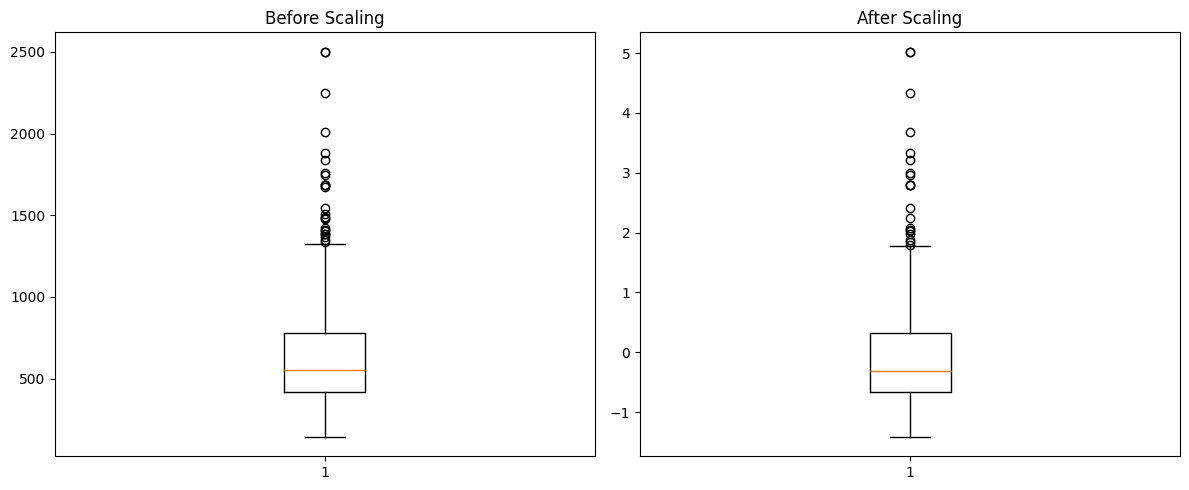

In [39]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(data[feature])
plt.title("Before Scaling")

plt.subplot(1,2,2)
plt.boxplot(X_train_scaled[feature])
plt.title("After Scaling")

plt.tight_layout()
plt.show()

In [40]:
print("Before Scaling:")
print("Mean:", data[feature].mean())
print("Std:", data[feature].std())

print("\nAfter Scaling:")
print("Mean:", X_train_scaled[feature].mean())
print("Std:", X_train_scaled[feature].std())

Before Scaling:
Mean: 654.8891036906855
Std: 351.9141291816527

After Scaling:
Mean: -1.1158020347991524e-17
Std: 1.0012586537392114
